In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Caricamento dati
df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
                             encoding='utf-8-sig',
                             index_col=False)

df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',
                        encoding='utf-8-sig',
                        index_col=False)
# Filtro Italia
df_elettriche_it = df_elettriche[df_elettriche['REF_AREA'] == 'IT'][['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Elettriche'})
df_ibride_it = df_ibride[df_ibride['REF_AREA'] == 'IT'][['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Ibride'})

# Merge e conversione
df_merged = pd.merge(df_elettriche_it, df_ibride_it, on='Anno')
df_merged['Elettriche'] = pd.to_numeric(df_merged['Elettriche'], errors='coerce')
df_merged['Ibride'] = pd.to_numeric(df_merged['Ibride'], errors='coerce')
df_merged = df_merged.dropna()

/var/folders/tg/8_yg9tkx2179wl4jrjqwhyzm0000gn/T/ipykernel_8021/561022936.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
/var/folders/tg/8_yg9tkx2179wl4jrjqwhyzm0000gn/T/ipykernel_8021/561022936.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',


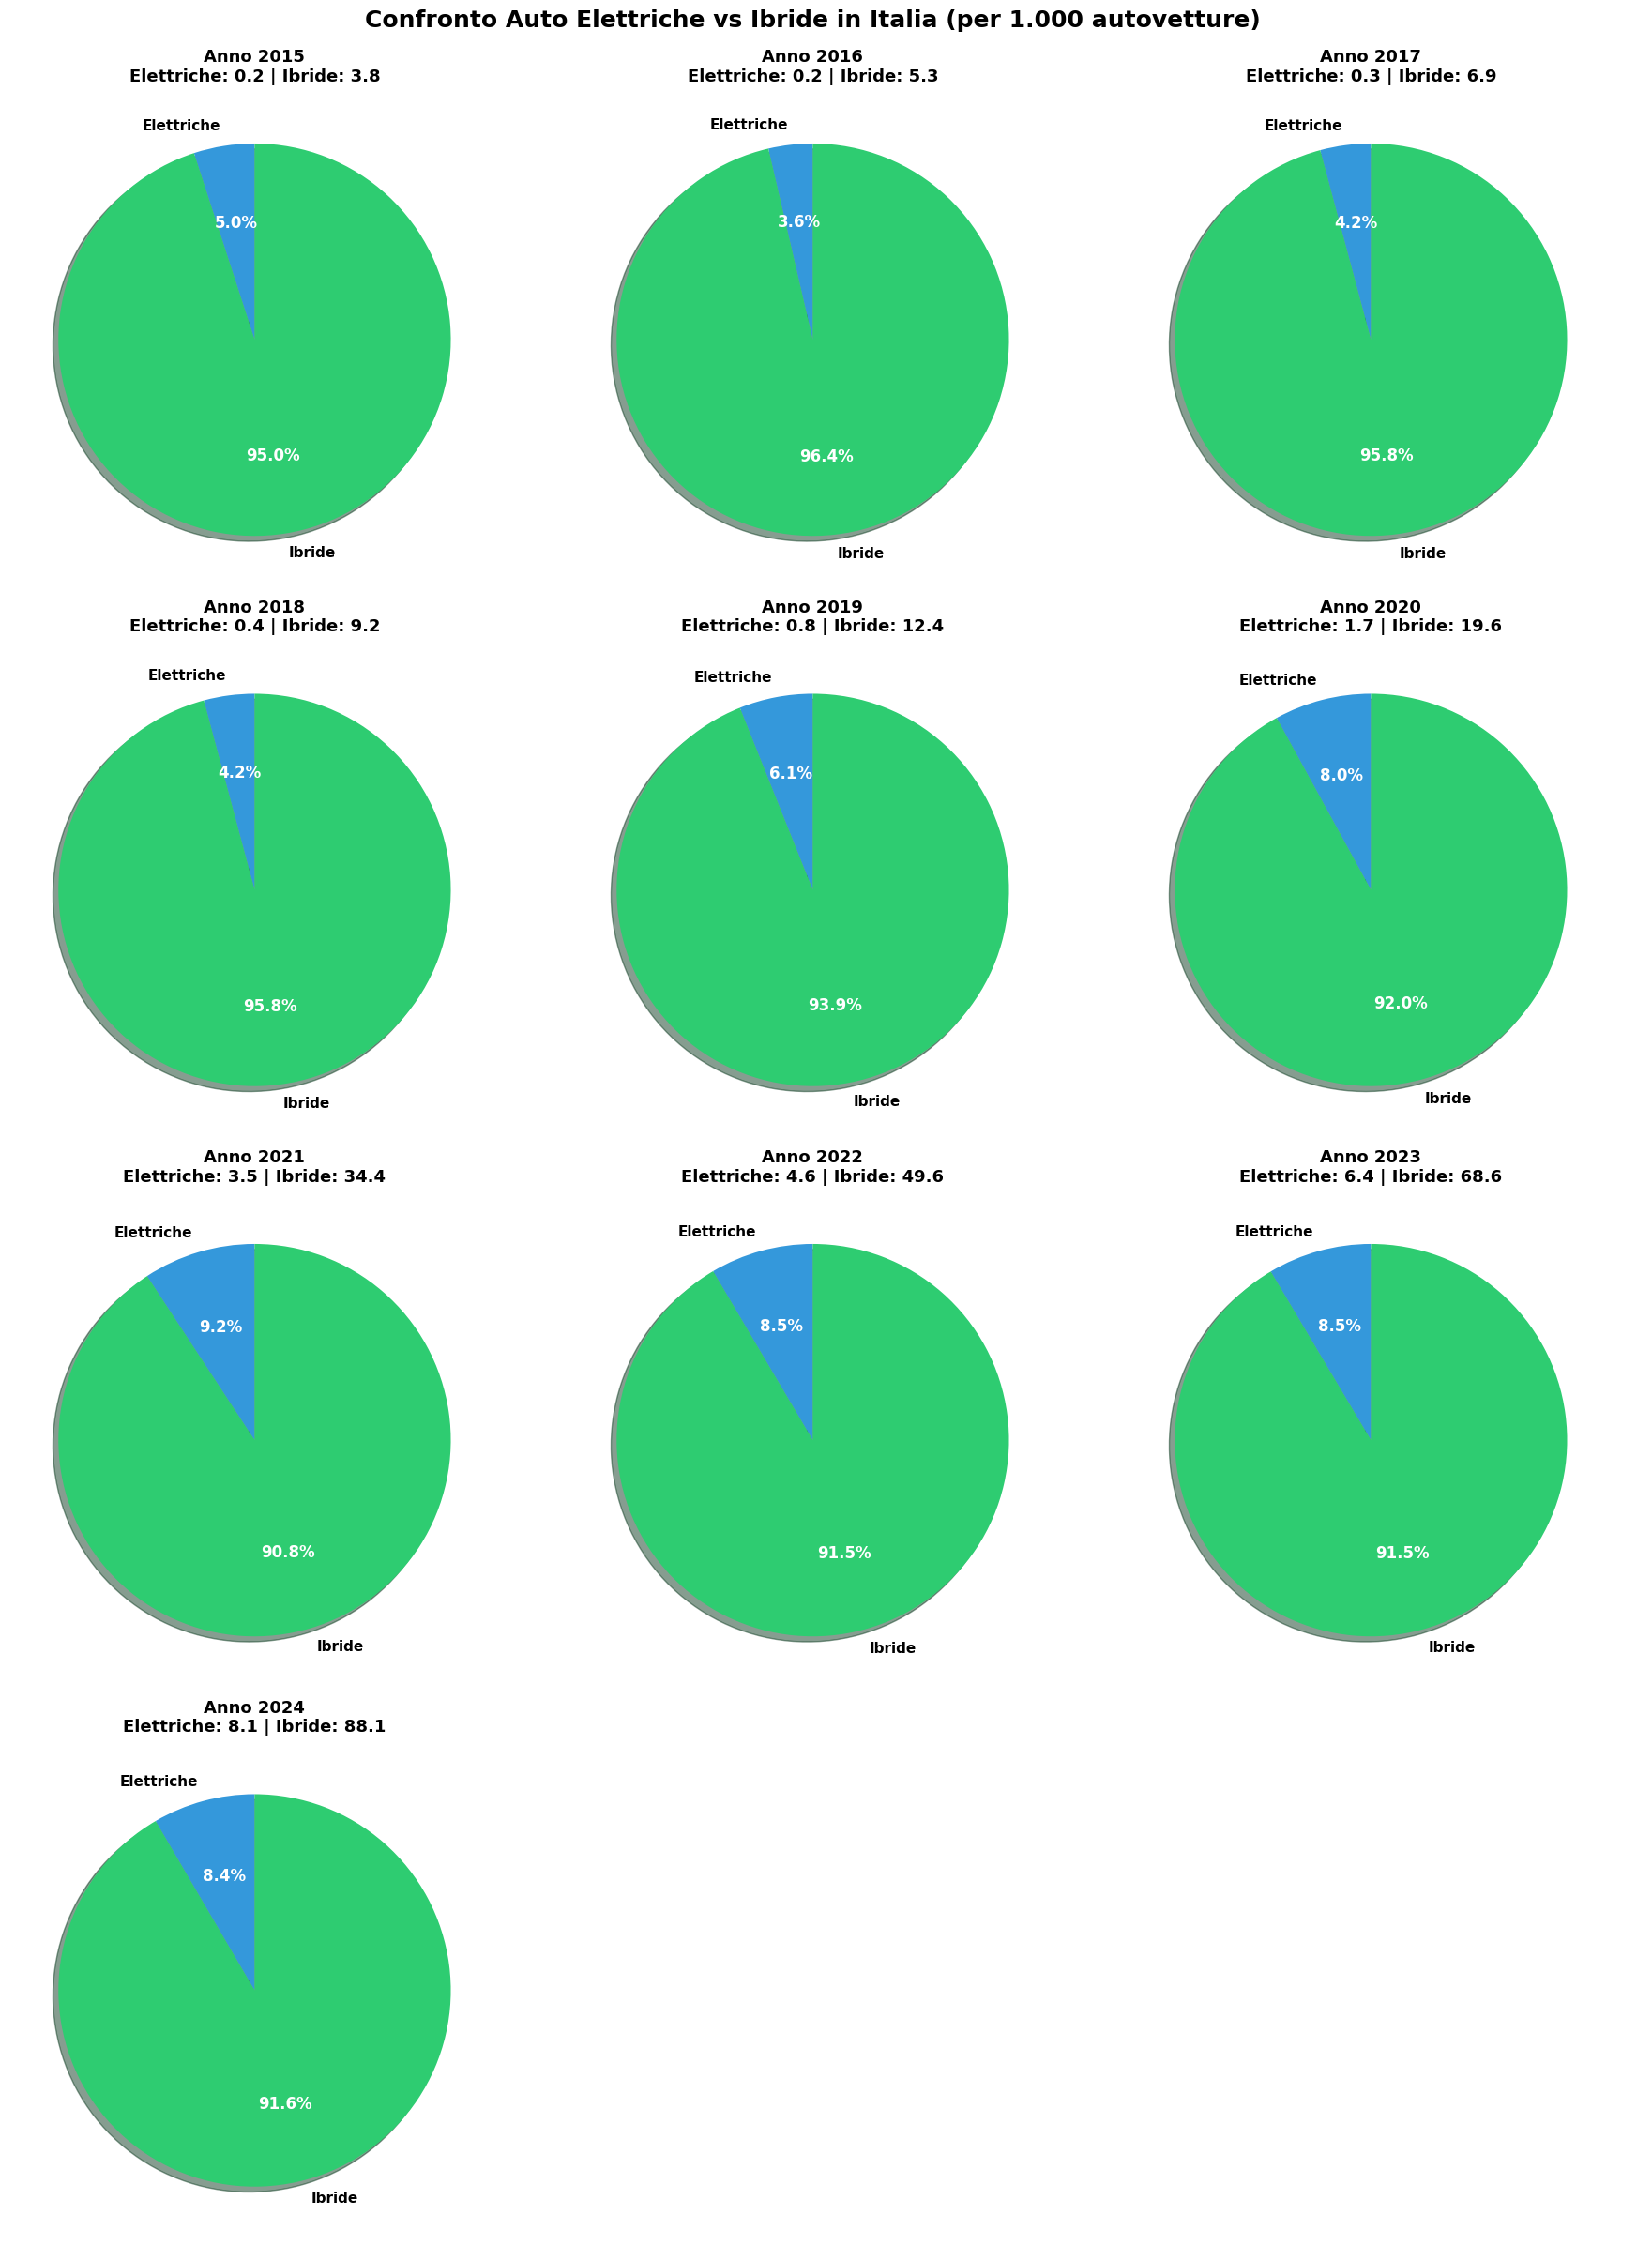

In [4]:
# Grafici a torta anno per anno
anni = sorted(df_merged['Anno'].unique())
n_anni = len(anni)
n_cols = 3
n_rows = int(np.ceil(n_anni / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Confronto Auto Elettriche vs Ibride in Italia (per 1.000 autovetture)', 
             fontsize=18, fontweight='bold', y=0.995)

axes = axes.flatten() if n_anni > 1 else [axes]
colori = ['#3498db', '#2ecc71']

for idx, anno in enumerate(anni):
    dati_anno = df_merged[df_merged['Anno'] == anno].iloc[0]
    valori = [dati_anno['Elettriche'], dati_anno['Ibride']]
    etichette = ['Elettriche', 'Ibride']
    
    wedges, texts, autotexts = axes[idx].pie(
        valori, 
        labels=etichette,
        autopct='%1.1f%%',
        startangle=90,
        colors=colori,
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_fontweight('bold')
    
    axes[idx].set_title(
        f'Anno {anno}\nElettriche: {valori[0]:.1f} | Ibride: {valori[1]:.1f}',
        fontsize=13,
        fontweight='bold',
        pad=10
    )

for idx in range(n_anni, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

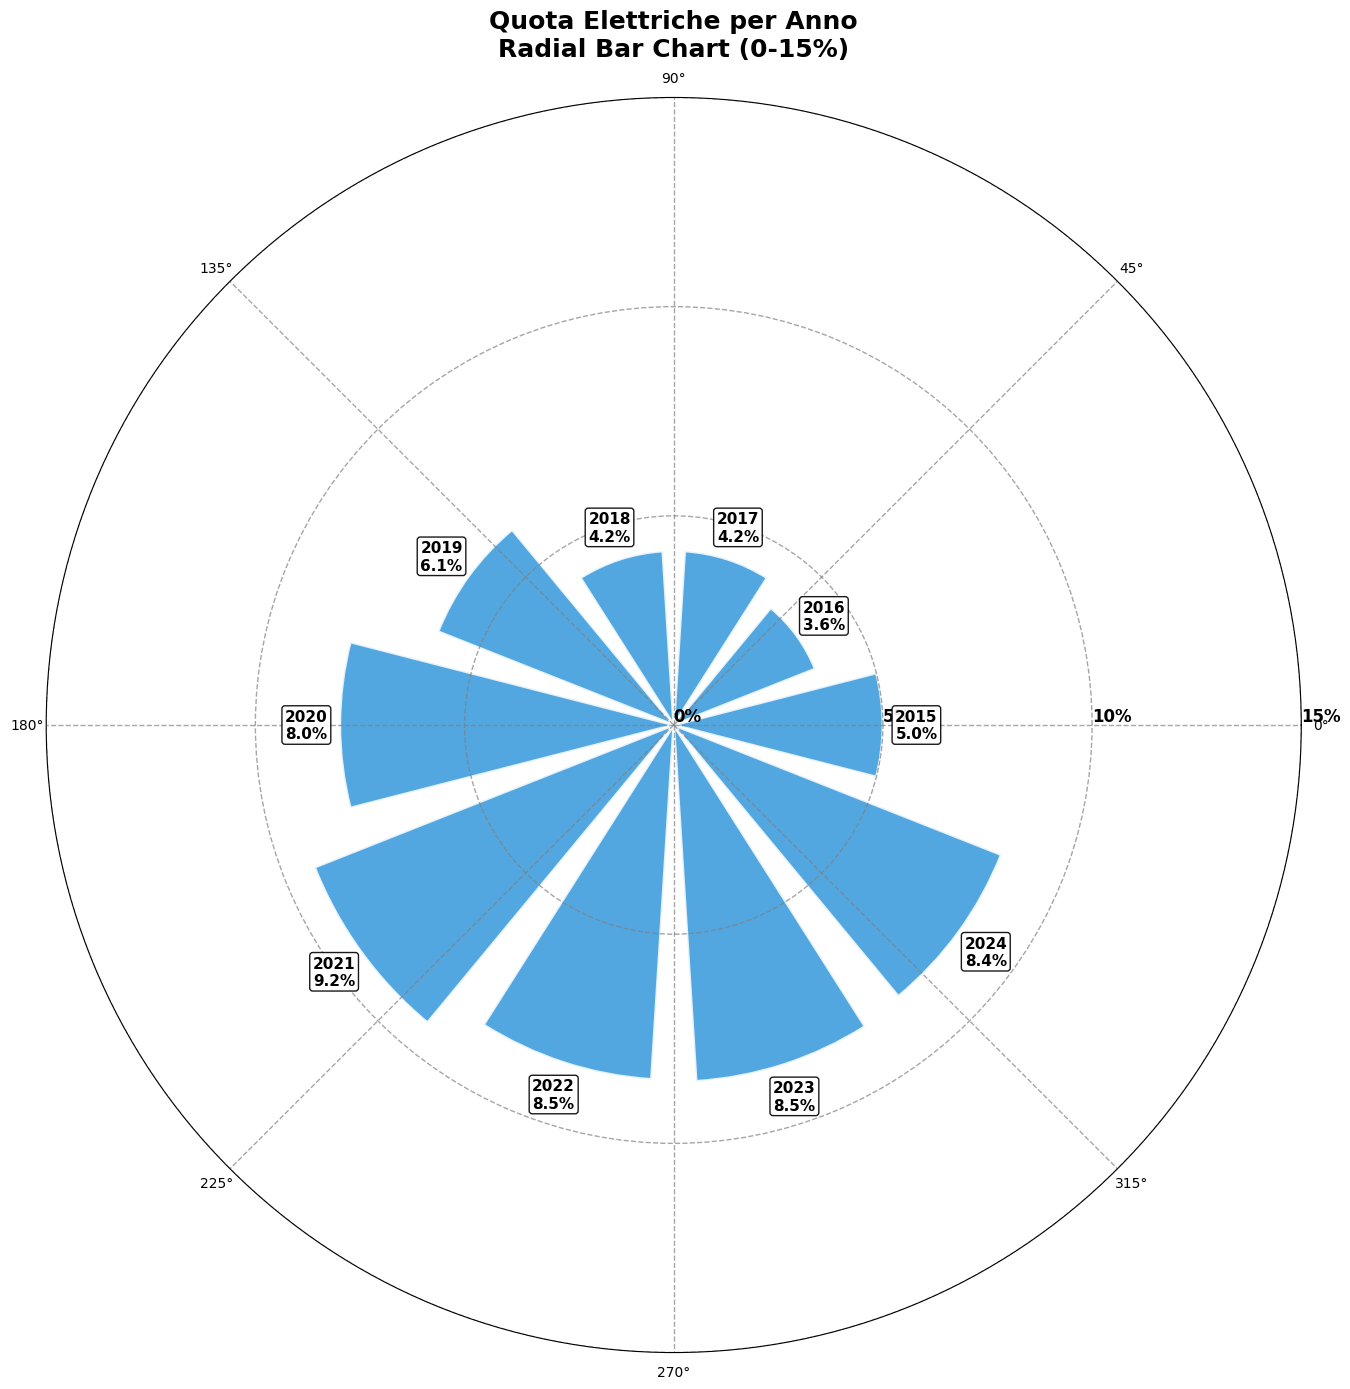

In [5]:
# VARIANTE TA4: RADIAL BAR - ASSE FINO 15%
import matplotlib.pyplot as plt
import numpy as np

anni = sorted(df_merged['Anno'].unique())
quota_elettriche = []
for anno in anni:
    dati = df_merged[df_merged['Anno'] == anno].iloc[0]
    quota = dati['Elettriche'] / (dati['Elettriche'] + dati['Ibride']) * 100
    quota_elettriche.append(quota)

fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2*np.pi, len(anni), endpoint=False)
width_angle = 2*np.pi / len(anni) * 0.8

# Barre radiali
bars = ax.bar(angles, quota_elettriche, width=width_angle, 
              color='#3498db', alpha=0.85, edgecolor='white', linewidth=2)

# ETICHETTE SU BORDO ESTERNO
for i, (angle, quota, anno) in enumerate(zip(angles, quota_elettriche, anni)):
    ax.text(angle, quota + 0.8, f'{anno}\n{quota:.1f}%', 
            ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))

# ASSE CORRETTO FINO 15%
ax.set_ylim(0, 15)  # ← CAMBIATO da 65 a 15
ax.set_yticks([0, 5, 10, 15])
ax.set_yticklabels(['0%', '5%', '10%', '15%'], fontsize=12, fontweight='bold')
ax.set_rlabel_position(0)
ax.grid(True, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Quota Elettriche per Anno\nRadial Bar Chart (0-15%)', 
             fontsize=18, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

In [ ]:
# VARIANTE TA1 COMPLETA: DONUT con % nelle FETTE COLORATE
import matplotlib.pyplot as plt
import numpy as np

anni = sorted(df_merged['Anno'].unique())
n_anni = len(anni)
n_cols = 3
n_rows = int(np.ceil(n_anni / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Elettriche vs Ibride per Anno\nDonut Charts - % nelle Fette Colorate\n\n', 
             fontsize=18, fontweight='bold', y=0.98)

axes = axes.flatten()
colori = ['#3498db', '#2ecc71']  # Blu, Verde

for idx, anno in enumerate(anni):
    dati_anno = df_merged[df_merged['Anno'] == anno].iloc[0]
    valori = [dati_anno['Elettriche'], dati_anno['Ibride']]
    
    # STEP 1: Pie donut (solo wedges)
    wedges = axes[idx].pie(valori, radius=1, labels=None, autopct=None,
                           startangle=90, colors=colori, shadow=False)[0]
    
    # STEP 2: Buco centrale
    centre_circle = plt.Circle((0, 0), 0.6, fc='#F8F9FA', linewidth=2, edgecolor='#DEE2E6')
    axes[idx].add_patch(centre_circle)
    
    # STEP 3: % CENTRATI nelle FETTE
    percentuali = [v/sum(valori)*100 for v in valori]
    for i, (wedge, pct) in enumerate(zip(wedges, percentuali)):
        # Calcola centro fetta
        ang = (wedge.theta2 - wedge.theta1)/2. + wedge.theta1
        x = 0.4 * np.cos(np.radians(ang))  # r=0.4 dentro fetta
        y = 0.4 * np.sin(np.radians(ang))
        
        # Colore testo contrastante
        text_color = "#000000" if i == 0 else "#000000"  # Bianco su blu, verde su verde
        axes[idx].text(x, y, f'{pct:.0f}%', fontsize=14, fontweight='bold',
                       ha='center', va='center', color=text_color)
    
    # STEP 4: Totale centrale buco
    totale = sum(valori)
    axes[idx].text(0, -0.05, f'{totale:.1f}', ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='#495057')
    
    # STEP 5: Titolo anno
    axes[idx].set_title(f'{anno}', fontsize=16, fontweight='bold', pad=10)

# Nascondi subplot vuoti
for idx in range(n_anni, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()



NameError: name 'df_merged' is not defined

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# FILTRA DAL 2016
anni = sorted(df_merged[df_merged['Anno'] >= 2016]['Anno'].unique())
n_anni = len(anni)
n_cols = 3
n_rows = int(np.ceil(n_anni / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Elettriche vs Ibride per Anno (dal 2016)\nDonut Charts - % nelle Fette Colorate\n\n', 
             fontsize=18, fontweight='bold', y=0.98)

axes = axes.flatten()
colori = ['#3498db', '#2ecc71']  # Blu Elettriche, Verde Ibride

for idx, anno in enumerate(anni):
    dati_anno = df_merged[df_merged['Anno'] == anno].iloc[0]
    valori = [dati_anno['Elettriche'], dati_anno['Ibride']]
    
    # STEP 1: Pie donut
    wedges = axes[idx].pie(valori, radius=1, labels=None, autopct=None,
                           startangle=90, colors=colori, shadow=False)[0]
    
    # STEP 2: Buco centrale
    centre_circle = plt.Circle((0, 0), 0.6, fc='#F8F9FA', linewidth=2, edgecolor='#DEE2E6')
    axes[idx].add_patch(centre_circle)
    
    # STEP 3: % CENTRATI nelle FETTE
    percentuali = [v/sum(valori)*100 for v in valori]
    for i, (wedge, pct) in enumerate(zip(wedges, percentuali)):
        ang = (wedge.theta2 - wedge.theta1)/2. + wedge.theta1
        x = 0.4 * np.cos(np.radians(ang))
        y = 0.4 * np.sin(np.radians(ang))
        text_color = "#FFFFFF" if i == 0 else "#1a1a1a"  # Bianco su blu, nero su verde
        axes[idx].text(x, y, f'{pct:.0f}%', fontsize=14, fontweight='bold',
                       ha='center', va='center', color=text_color)
    
    # STEP 4: Totale centrale
    totale = sum(valori)
    axes[idx].text(0, -0.05, f'{totale:.1f}', ha='center', va='center', 
                   fontsize=16, fontweight='bold', color='#495057')
    
    # STEP 5: Titolo anno
    axes[idx].set_title(f'{anno}', fontsize=16, fontweight='bold', pad=10)

# Nascondi subplot vuoti
for idx in range(n_anni, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


NameError: name 'df_merged' is not defined